In [46]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt




def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    if epochs is not None:
        epoch_dirs = [d for d in all_subdirs if "epoch" in d]
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
        all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    if not base:
        all_subdirs = [d for d in all_subdirs if "base" not in d]

    if not retrain:
        all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # remove any unnecessary classes, percents, runs
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if percents is not None:
            pattern = rf"percent_({'|'.join(map(str, percents))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if runs is not None:
            pattern = rf"run_({'|'.join(map(str, runs))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add percent if none
            match = re.search(r'percent_(\d+)', f)
            if match:
                data['percent'] = int(match.group(1))
            else:
                data['percent'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            # add run if none
            match = re.search(r'run_(\d+)', f)
            if match:
                data['run'] = int(match.group(1))
            else:
                data['run'] = -99  # default value if no match

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    if "MIA" in final_df.columns:

        expanded_MIA = pd.json_normalize(final_df['MIA'])

        # json_normalize resets the index, so you MUST align it with your original dataframe
        expanded_MIA.index = final_df.index

        # Optional prefixing
        expanded_MIA = expanded_MIA.add_prefix('MIA_')

        # 2. Drop the original nested column and concatenate
        final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_scatterplot(final_df, x_metric, y_metric, 
                        color_by = "epoch", 
                        base_color = "black", retain_color = "purple"
                        ):

    
    # set up colors
    unique_epochs = sorted(final_df[color_by].unique())
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for epoch in unique_epochs:
        if epoch == -99:
            palette_dict[epoch] = base_color
        elif epoch == -98:
            palette_dict[epoch] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 epochs
            palette_dict[epoch] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # 2. Replace -99 (or -99.0) with "base" in the labels list
    new_labels = ["base" if label == "-99" or label == "-99.0" else "retrain" if label == "-98" or label == "-98.0" else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [47]:
results = gather_results("results/seed_3011")
results

,forget_loss,forget_acc,forget_entr,forget_m_entr,retain_loss,retain_acc,retain_entr,retain_m_entr,test_loss,test_acc,...,class,percent,MIA_correctness.retain_test_member,MIA_correctness.forget_non_member,MIA_confidence.retain_test_member,MIA_confidence.forget_non_member,MIA_entropy.retain_test_member,MIA_entropy.forget_non_member,MIA_m_entropy.retain_test_member,MIA_m_entropy.forget_non_member
0,0.385876,85.04,0.349373,0.458851,0.093679,96.937778,0.132228,0.093971,0.319184,90.28,...,5,-99,0.970444,0.1496,0.945556,1.0,0.909889,1.0,0.948333,1.0
0,4.098774,28.26,0.653938,5.316244,0.874476,78.613333,0.279743,1.219953,1.21609,74.87,...,5,-99,0.786111,0.7174,0.909556,1.0,0.652111,1.0,0.917444,1.0
0,2.59788,42.0,0.616742,3.415505,0.480762,86.357778,0.230702,0.652671,0.817065,81.08,...,5,-99,0.862667,0.5800,0.946111,1.0,0.863667,1.0,0.945889,1.0
0,0.908417,68.78,0.498771,1.188336,0.139612,95.313333,0.15107,0.160495,0.414465,87.74,...,5,-99,0.947222,0.3122,0.938444,1.0,0.496667,1.0,0.943000,1.0
0,5.226101,20.06,0.652593,6.733888,1.24111,72.175556,0.313835,1.750764,1.572852,70.25,...,5,-99,0.722000,0.7994,0.814556,1.0,0.654444,1.0,0.808000,1.0


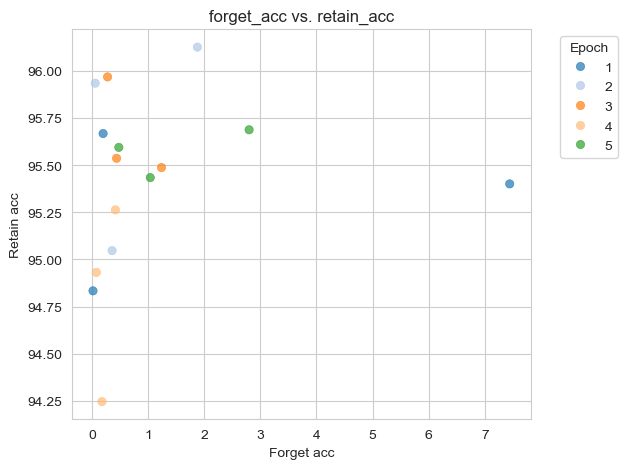

In [50]:
results = gather_results("results/seed_3012", base=False, retrain=False) 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "retain_acc", 
    color_by = "epoch"
    )